# 03 - Behavioural Cloning (M3, M4, M5, M8 + RQ1-RQ4)

**Group members:** _add names here_

BC trains a student to regress the expert's action from the observation. We run the `imitation` library BC and a from-scratch PyTorch BC, an epoch sweep, a dataset-size ablation, and an architecture sweep. We study **both** Walker2d experts (the strong 6043 and the gentler generic 4627) plus Ant. Produced by `bc_experiments.py` and `arch_sweep.py`.

Key implementation note: the experts use VecNormalize, so BC trains and evaluates on the same normalised observations, and the from-scratch BC uses validation-loss early stopping (spec-recommended).

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
OUT, MODELS, LOGS = ROOT/'outputs', ROOT/'models', ROOT/'logs'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('missing figure:', name)
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok')

setup ok


## M3/M4 - Library BC vs from-scratch BC, and the expert gap

In [2]:
keys = {'Walker2d-v4':'Walker2d (6043)', 'Walker2d-v4_generic_backup':'Walker2d (4627)', 'Ant-v4':'Ant (6293)'}
rows = []
for k, label in keys.items():
    r = results(f'bc_results_{k}.json')
    em = r.get('expert_mean'); lib = r['library_bc']['mean']; scr = r['scratch_bc']['mean']
    rows.append(dict(config=label, expert=round(em), library_BC=round(lib),
        lib_pct=f'{100*lib/em:.0f}%', scratch_BC=round(scr), scratch_pct=f'{100*scr/em:.0f}%',
        scratch_valMSE=round(r['scratch_bc']['val_mse'],4)))
pd.DataFrame(rows)

,config,expert,library_BC,lib_pct,scratch_BC,scratch_pct,scratch_valMSE
0,Walker2d (6043),6044,5719,95%,4238,70%,0.0131
1,Walker2d (4627),4700,4591,98%,4160,89%,0.0032
2,Ant (6293),6180,6237,101%,5753,93%,0.0003


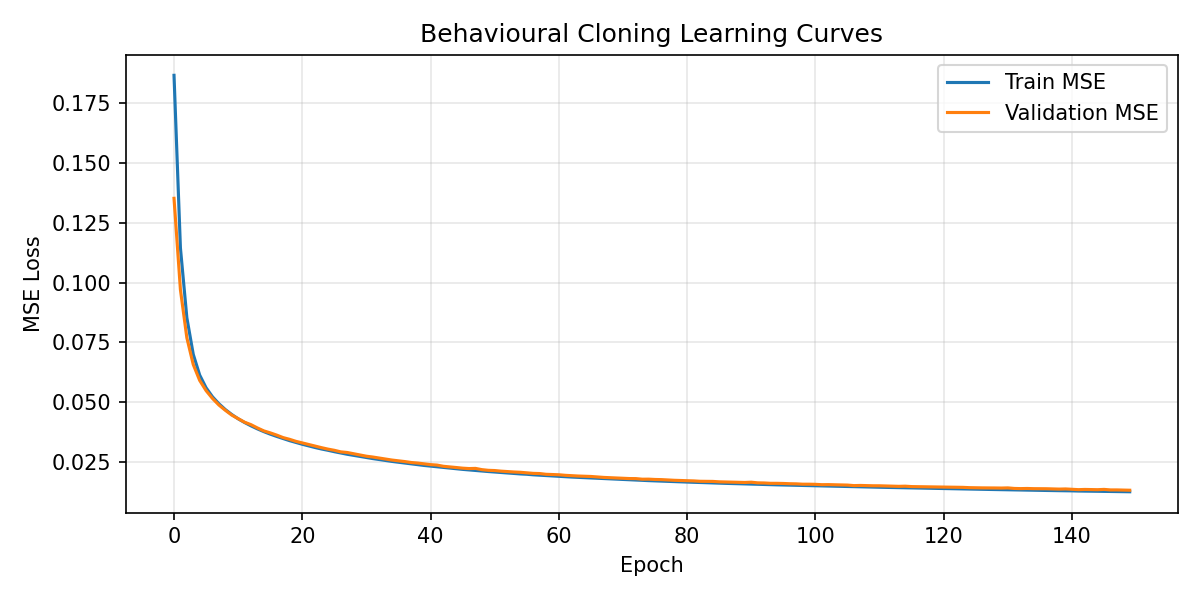

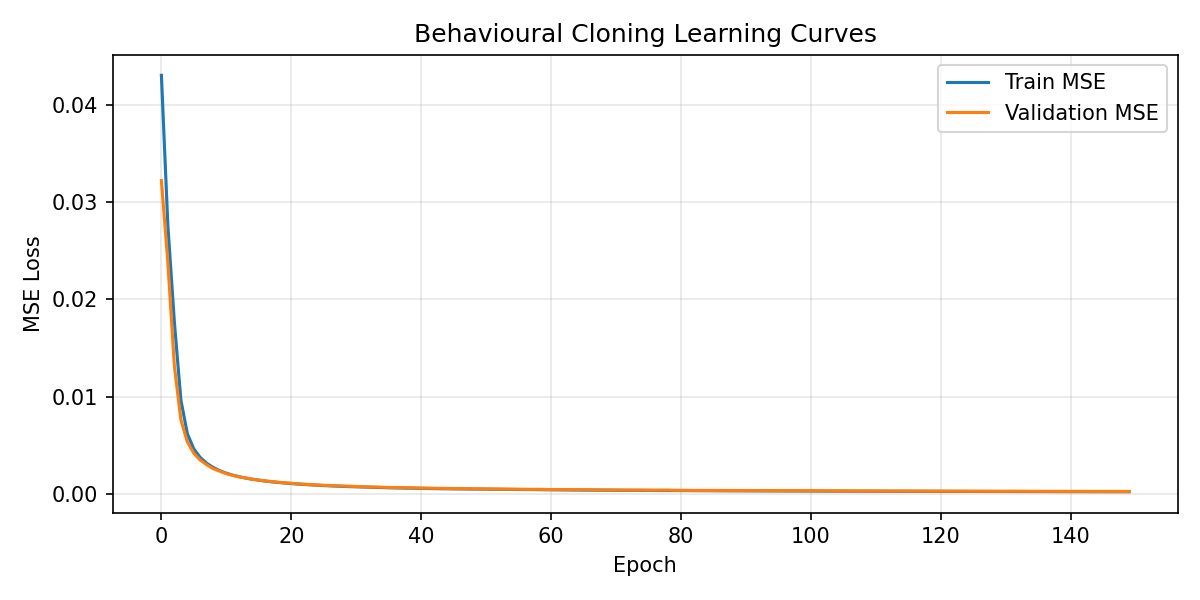

In [3]:
show('bc_learning_curves_Walker2d-v4.png')
show('bc_learning_curves_Ant-v4.png')

## M3 - Epoch sweep (how performance evolves with training epochs)

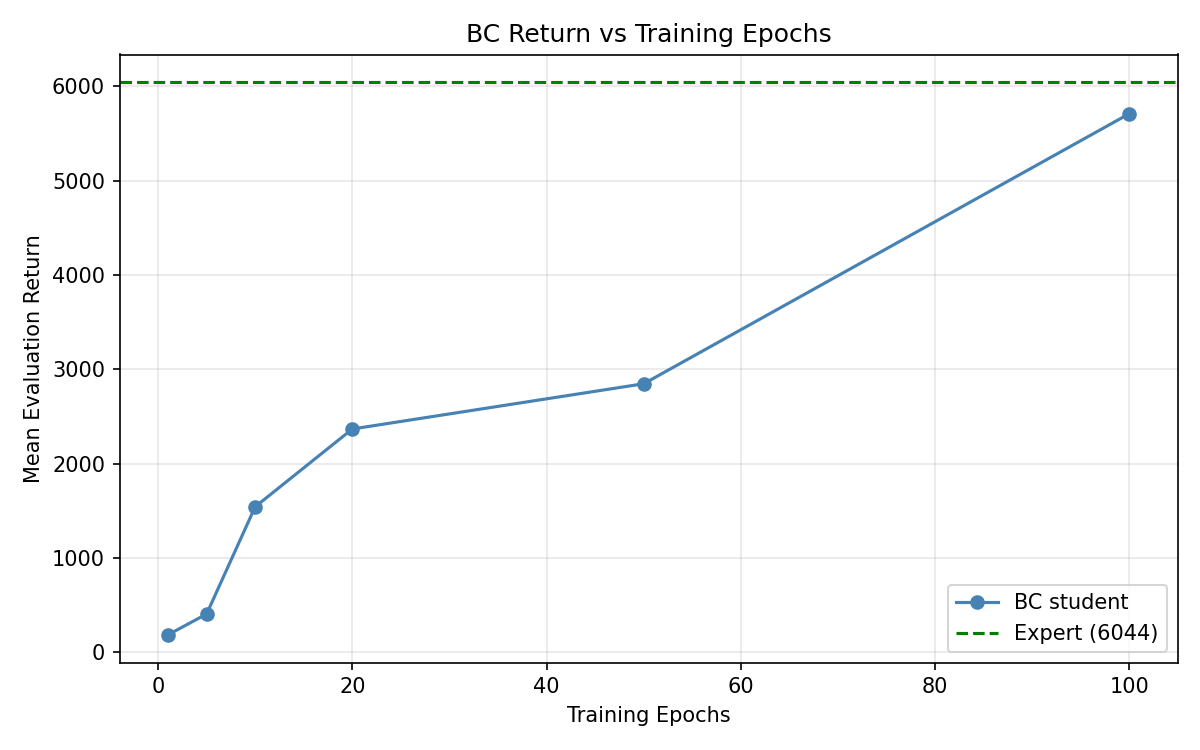

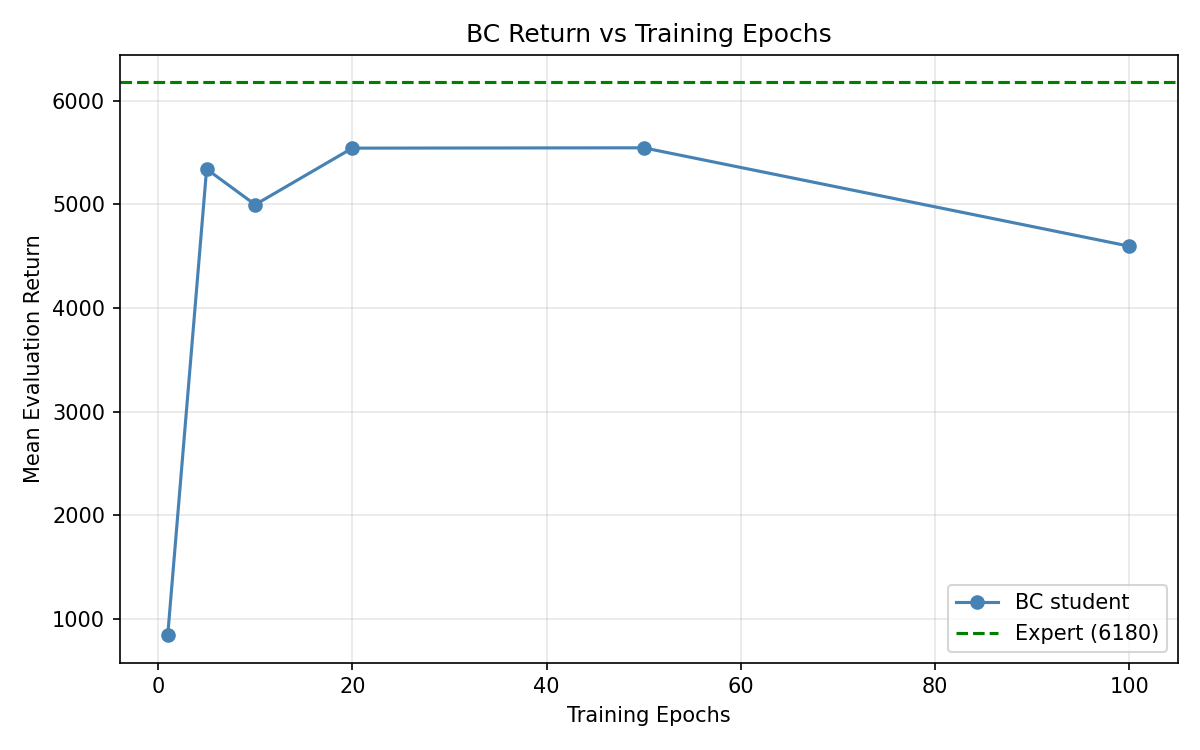

In [4]:
show('bc_epoch_sweep_Walker2d-v4.png')
show('bc_epoch_sweep_Ant-v4.png')

## M5 - Dataset-size ablation ({5,10,20,50,100} episodes x 5 seeds)

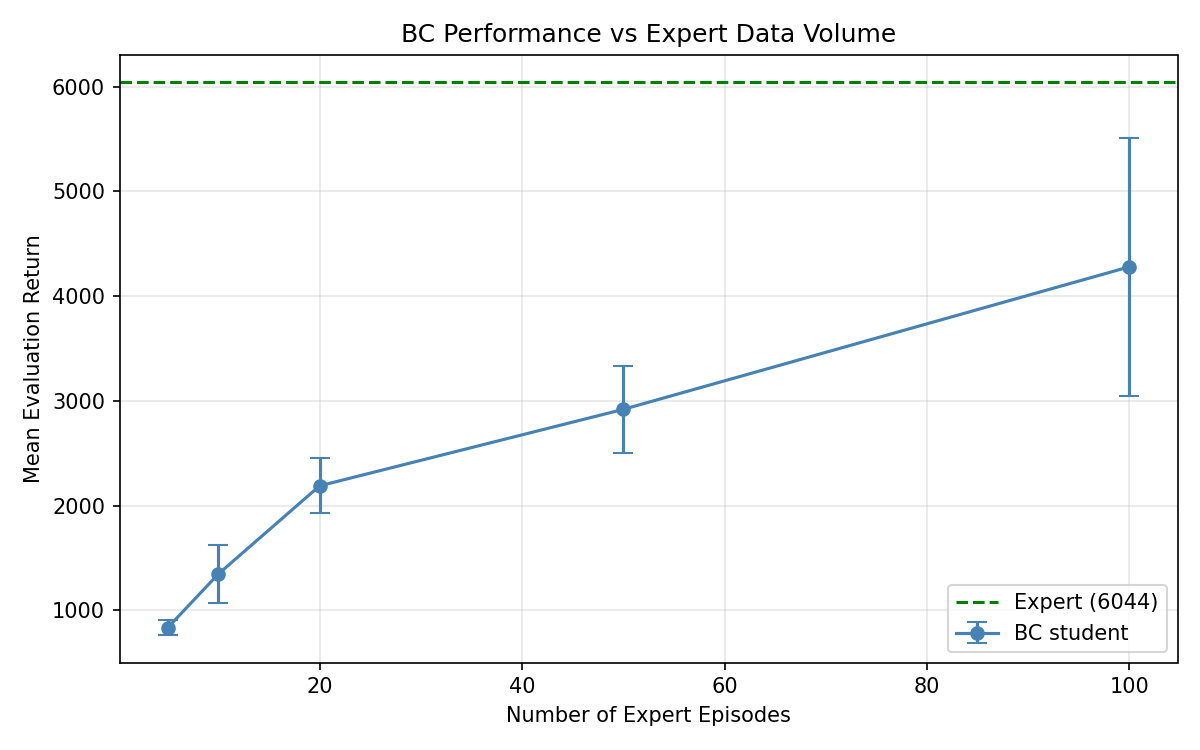

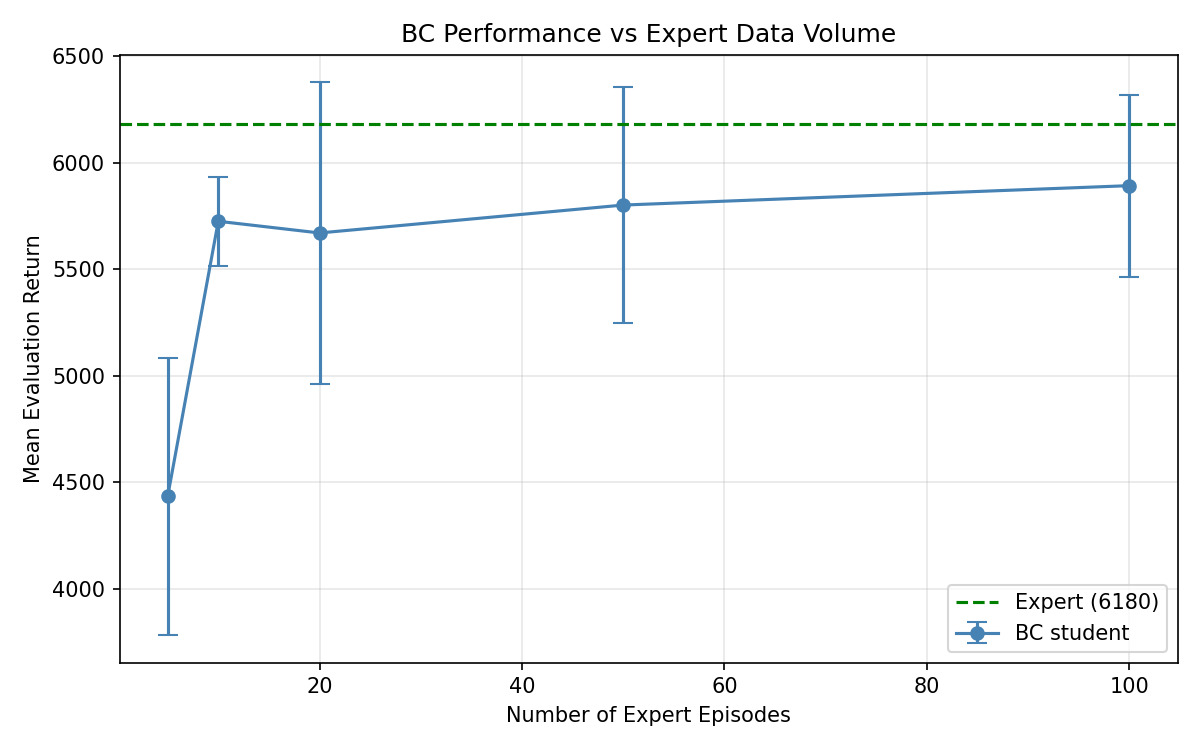

In [5]:
show('bc_ablation_data_size_Walker2d-v4.png')
show('bc_ablation_data_size_Ant-v4.png')

## M8 - Architecture sweep (5 seeds)

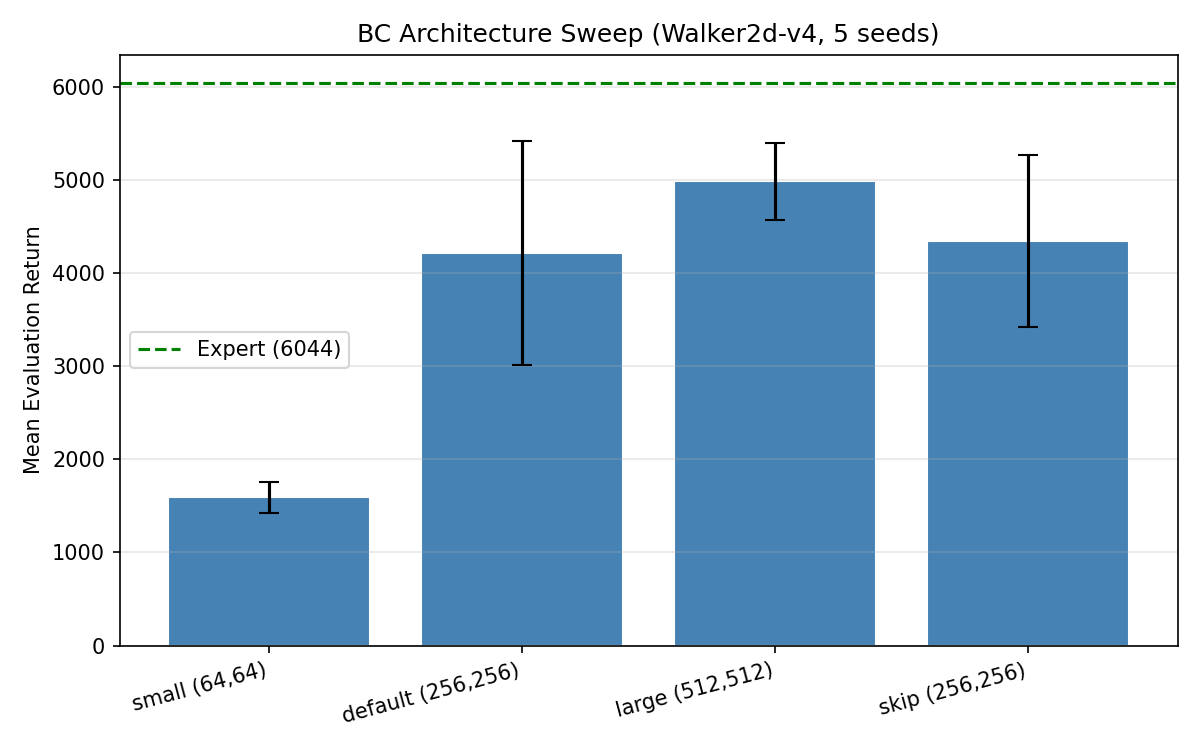

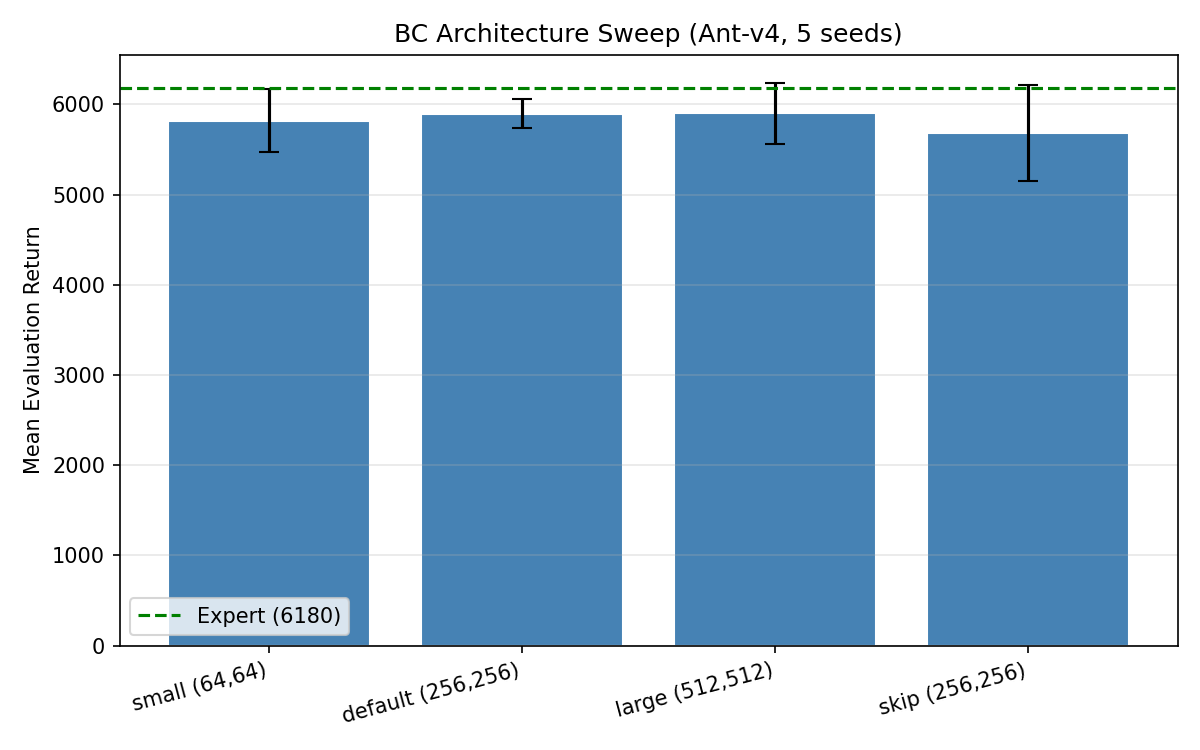

In [6]:
show('bc_arch_sweep_Walker2d-v4.png')
show('bc_arch_sweep_Ant-v4.png')

## RQ1 - How close can BC get to the expert, and what limits the gap?

**Close, given enough training.** Library BC recovers **95%** of the Walker2d-6043 expert and **99%** of the Ant expert. The main limiter we observed was not a fundamental imitation ceiling but the **training budget**: at 50 epochs the strong Walker2d student reached only ~47%, and only with more epochs / early stopping did it climb to 95%. The residual gap is driven by the expert's near-saturated control (small action errors compound over the long horizon, the classic BC distribution-mismatch argument). Evidence: the BC-vs-expert table, the epoch sweep, and the higher residual gap for the more aggressive expert.

## RQ2 - How does the amount of expert data affect the student?

Performance **rises steeply then saturates**. The ablation shows a sharp climb from 5 to ~50 episodes, after which extra data adds little; small datasets (5-10 episodes) are both low-return and high-variance across seeds. Practically, ~50 demonstrations capture most of the achievable performance for these tasks.

## RQ3 - Does lower BC loss imply a better policy?

**No, not reliably.** Online return and offline action-MSE do not move together. The clearest evidence: at a fixed (low) validation MSE the evaluation return still varies by ~1000+ across seeds, and the 50-epoch Walker2d student had a respectable MSE yet poor return. Because imitation is evaluated in a sequential setting, small per-step errors compound, so a lower supervised loss is necessary but not sufficient for a strong policy.

## RQ4 - How much does student architecture matter?

**It matters, and env-dependently.** On Walker2d a larger MLP (512,512) clearly wins and a small (64,64) net underfits badly; on Ant all architectures cluster tightly (the mapping is easier to fit, val MSE ~5e-4) and skip connections are only marginally best. So capacity helps most on the harder-to-fit environment; for easy ones a compact student suffices (relevant to the model-compression motivation for imitation).